# Chapter 268 - Continuous Distributions Zoo

**Part VIII - Probability**

Beyond the normal distribution (ch253) lies a rich ecosystem of continuous distributions, each adapted to specific data-generating processes. This chapter builds the exponential, gamma, chi-squared, t, F, and beta distributions from first principles, showing how they connect and when to use each.

## 1. Exponential Distribution - Waiting Times

The exponential distribution is the continuous analogue of the geometric: it models the waiting time to the first event in a Poisson process (ch252). Its defining property is memorylessness.

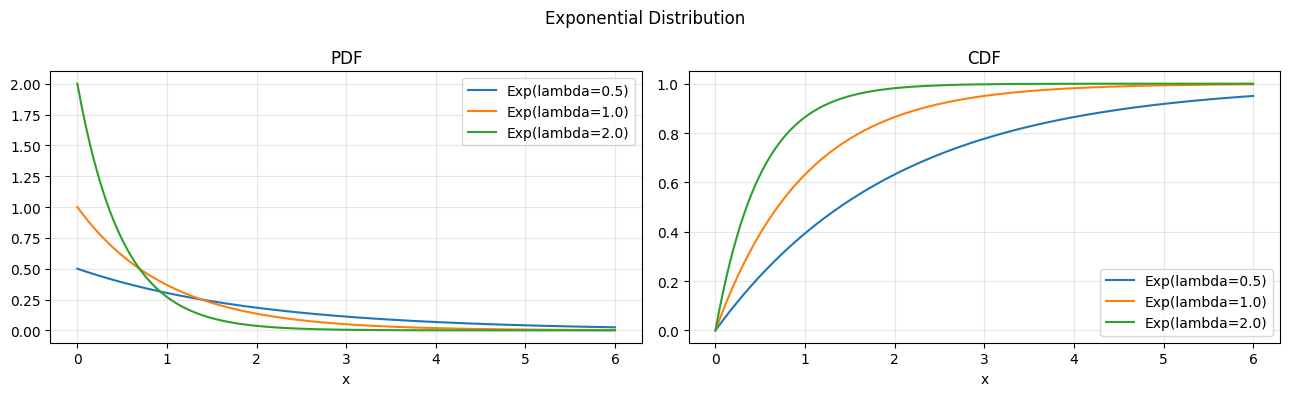

P(X > 1.0+0.5 | X > 1.0) = 0.6062
P(X > 0.5)              = 0.6066
Memoryless verified: difference = 0.0004


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, gamma, chi2

rng = np.random.default_rng(7)

# --- Exponential Distribution ---
# X ~ Exp(lambda): waiting time between Poisson events (ch252)
# PDF: f(x) = lambda * exp(-lambda * x),  x >= 0
# CDF: F(x) = 1 - exp(-lambda * x)
# Mean: 1/lambda,  Var: 1/lambda^2
# Memoryless: P(X > s+t | X > s) = P(X > t)

x = np.linspace(0, 6, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for lam, col in zip([0.5, 1.0, 2.0], ["C0", "C1", "C2"]):
    axes[0].plot(x, expon.pdf(x, scale=1/lam), color=col, label=f"Exp(lambda={lam})")
    axes[1].plot(x, expon.cdf(x, scale=1/lam), color=col, label=f"Exp(lambda={lam})")
axes[0].set_title("PDF"); axes[1].set_title("CDF")
for ax in axes: ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel("x")
plt.suptitle("Exponential Distribution"); plt.tight_layout(); plt.show()

# Verify memoryless property empirically
s, t = 1.0, 0.5
samples_exp = rng.exponential(scale=1.0, size=200_000)
p_gt_s_t_given_gt_s = np.mean(samples_exp[samples_exp > s] > s + t)
p_gt_t              = np.mean(samples_exp > t)
print(f"P(X > {s}+{t} | X > {s}) = {p_gt_s_t_given_gt_s:.4f}")
print(f"P(X > {t})              = {p_gt_t:.4f}")
print(f"Memoryless verified: difference = {abs(p_gt_s_t_given_gt_s - p_gt_t):.4f}")


## 2. Gamma Distribution - Sum of Waiting Times

If the exponential models one waiting time, the gamma models the sum of k independent waiting times. It is the bridge between the exponential and the normal (via CLT, ch254).

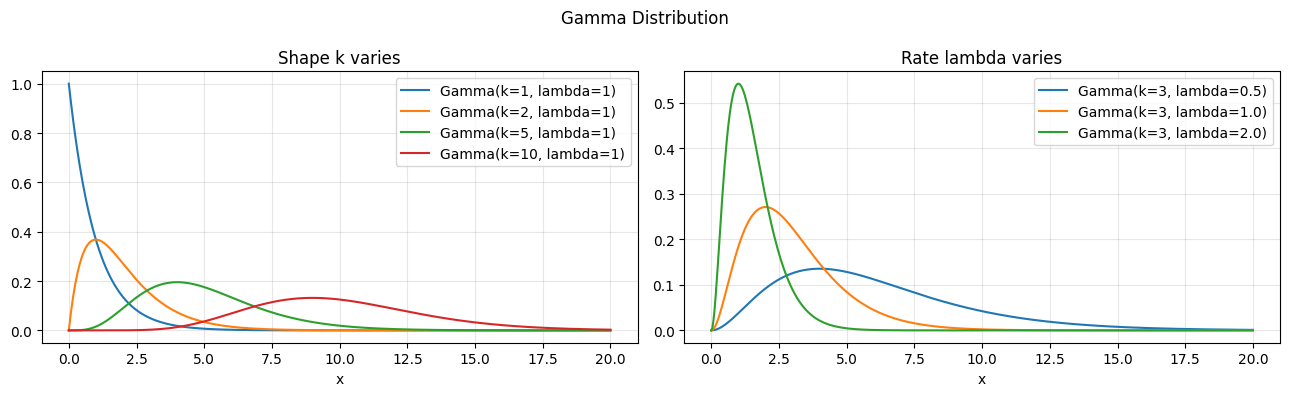

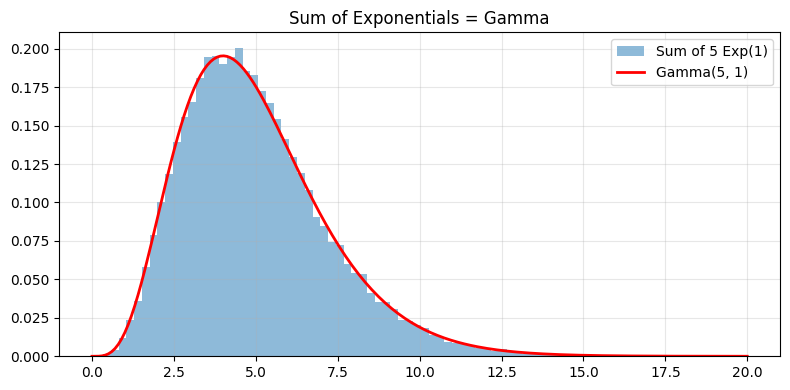

In [2]:
# Gamma Distribution: sum of k independent Exp(lambda) variables
# X ~ Gamma(k, lambda): shape k, rate lambda
# PDF: f(x) = lambda^k * x^(k-1) * exp(-lambda*x) / Gamma(k)
# Mean: k/lambda, Var: k/lambda^2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.linspace(0, 20, 500)
for k, col in zip([1, 2, 5, 10], ["C0", "C1", "C2", "C3"]):
    axes[0].plot(x, gamma.pdf(x, a=k, scale=1.0), color=col, label=f"Gamma(k={k}, lambda=1)")
for lam, col in zip([0.5, 1.0, 2.0], ["C0", "C1", "C2"]):
    axes[1].plot(x, gamma.pdf(x, a=3, scale=1/lam), color=col, label=f"Gamma(k=3, lambda={lam})")
axes[0].set_title("Shape k varies"); axes[1].set_title("Rate lambda varies")
for ax in axes: ax.legend(); ax.grid(alpha=0.3); ax.set_xlabel("x")
plt.suptitle("Gamma Distribution"); plt.tight_layout(); plt.show()

# Verify: sum of k Exp(1) ~ Gamma(k, 1)
k_test = 5
sum_of_exp = rng.exponential(1.0, size=(50_000, k_test)).sum(axis=1)
xs = np.linspace(0, 20, 200)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(sum_of_exp, bins=80, density=True, alpha=0.5, label=f"Sum of {k_test} Exp(1)")
ax.plot(xs, gamma.pdf(xs, a=k_test, scale=1.0), "r-", lw=2, label=f"Gamma({k_test}, 1)")
ax.legend(); ax.grid(alpha=0.3); ax.set_title("Sum of Exponentials = Gamma")
plt.tight_layout(); plt.show()


## 3. Chi-Squared Distribution - Sums of Squared Normals

The chi-squared distribution with k degrees of freedom is Gamma(k/2, 1/2). It arises naturally when squaring and summing standard normals, making it central to variance estimation and goodness-of-fit testing.

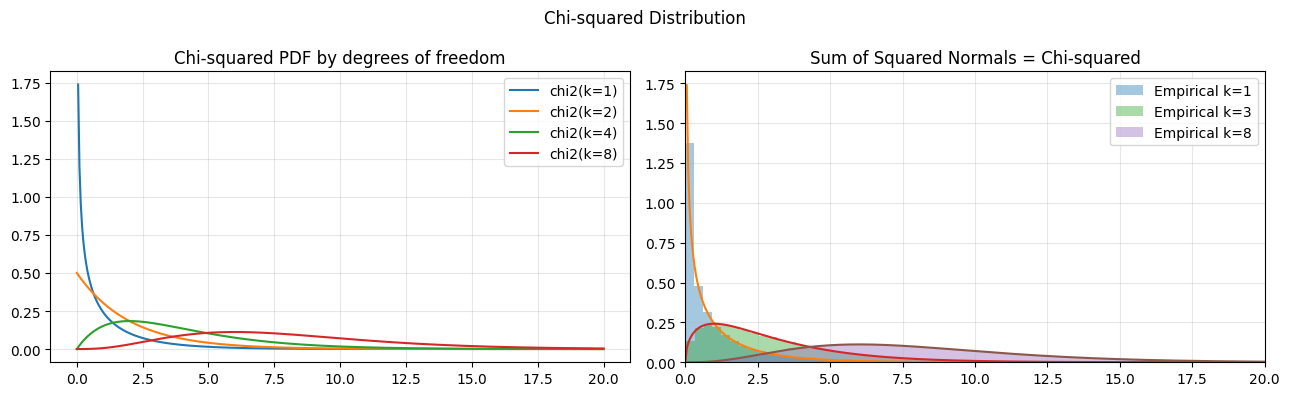

Chi-squared(k) = Gamma(k/2, 1/2)


In [3]:
# Chi-squared distribution: Gamma(k/2, 1/2)
# X ~ chi2(k): sum of k squared standard normals
# Z_1,...,Z_k iid N(0,1) => Z_1^2+...+Z_k^2 ~ chi2(k)
# Critical in hypothesis testing (ch280) and confidence intervals (ch281)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.linspace(0, 20, 400)
for dof in [1, 2, 4, 8]:
    axes[0].plot(x, chi2.pdf(x, df=dof), label=f"chi2(k={dof})")
axes[0].set_title("Chi-squared PDF by degrees of freedom")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Verify: sum of squares of standard normals
for k in [1, 3, 8]:
    emp = rng.standard_normal(size=(50_000, k))**2
    emp_sum = emp.sum(axis=1)
    axes[1].hist(emp_sum, bins=80, density=True, alpha=0.4, label=f"Empirical k={k}")
    axes[1].plot(x, chi2.pdf(x, df=k), lw=1.5)
axes[1].set_xlim(0, 20); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title("Sum of Squared Normals = Chi-squared")
plt.suptitle("Chi-squared Distribution"); plt.tight_layout(); plt.show()
print("Chi-squared(k) = Gamma(k/2, 1/2)")


## 4. The t and F Distributions - Statistical Inference Workhorses

These distributions are derived from normal and chi-squared components. They arise when estimating population parameters from samples where the true variance is unknown.

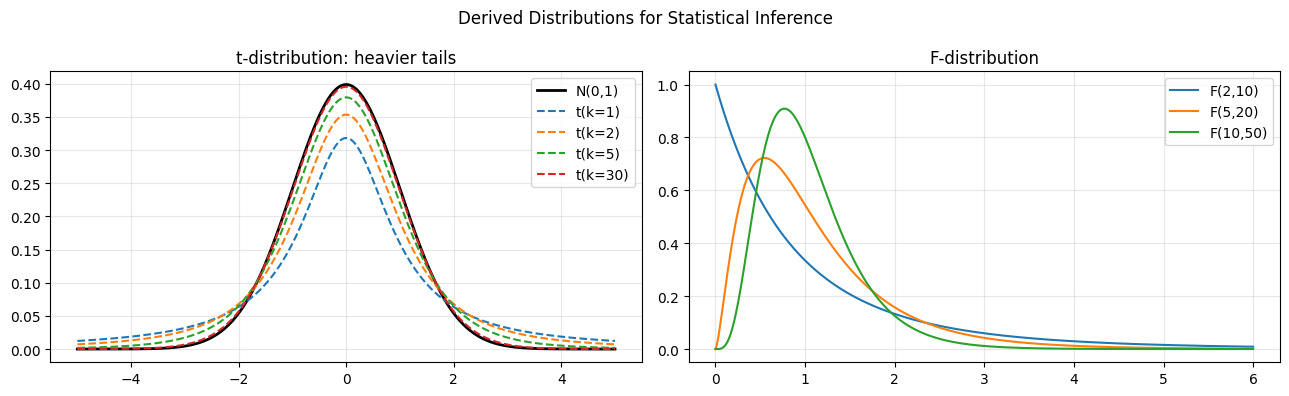

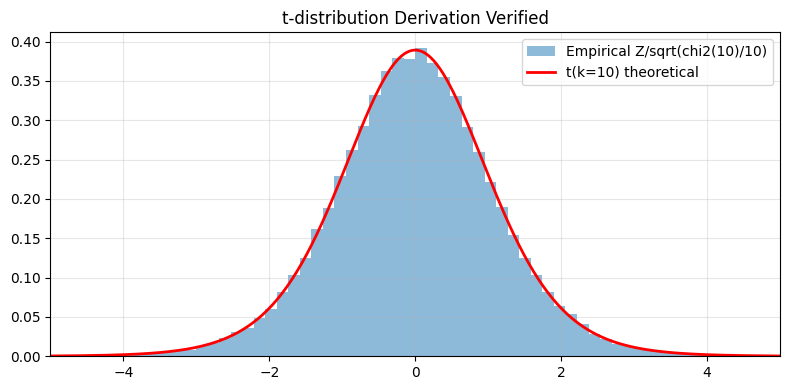

In [4]:
from scipy.stats import t as t_dist, f as f_dist

# t-distribution: ratio of standard normal to sqrt(chi2/k)/k
# T = Z / sqrt(chi2(k)/k),  Z ~ N(0,1) independent of chi2(k)
# Heavier tails than normal; converges to N(0,1) as k->inf

x = np.linspace(-5, 5, 400)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
from scipy.stats import norm
axes[0].plot(x, norm.pdf(x), "k-", lw=2, label="N(0,1)")
for dof, col in zip([1, 2, 5, 30], ["C0","C1","C2","C3"]):
    axes[0].plot(x, t_dist.pdf(x, df=dof), color=col, ls="--", label=f"t(k={dof})")
axes[0].set_title("t-distribution: heavier tails"); axes[0].legend(); axes[0].grid(alpha=0.3)

# F-distribution: ratio of two chi-squared / degrees of freedom
x_f = np.linspace(0, 6, 400)
for d1, d2 in [(2,10), (5,20), (10,50)]:
    axes[1].plot(x_f, f_dist.pdf(x_f, dfn=d1, dfd=d2), label=f"F({d1},{d2})")
axes[1].set_title("F-distribution"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Derived Distributions for Statistical Inference"); plt.tight_layout(); plt.show()

# Verify empirically
z_samples = rng.standard_normal(100_000)
chi2_samples = rng.chisquare(df=10, size=100_000)
t_empirical = z_samples / np.sqrt(chi2_samples / 10)
xs = np.linspace(-5, 5, 300)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(t_empirical, bins=100, density=True, alpha=0.5, label="Empirical Z/sqrt(chi2(10)/10)")
ax.plot(xs, t_dist.pdf(xs, df=10), "r-", lw=2, label="t(k=10) theoretical")
ax.set_xlim(-5, 5); ax.legend(); ax.grid(alpha=0.3); ax.set_title("t-distribution Derivation Verified")
plt.tight_layout(); plt.show()


## 5. Beta Distribution - Modeling Probabilities

The beta distribution lives on [0,1], making it the natural model for probabilities, proportions, and rates. It is the conjugate prior for the binomial likelihood *(ch261 - Bayesian Inference)*.

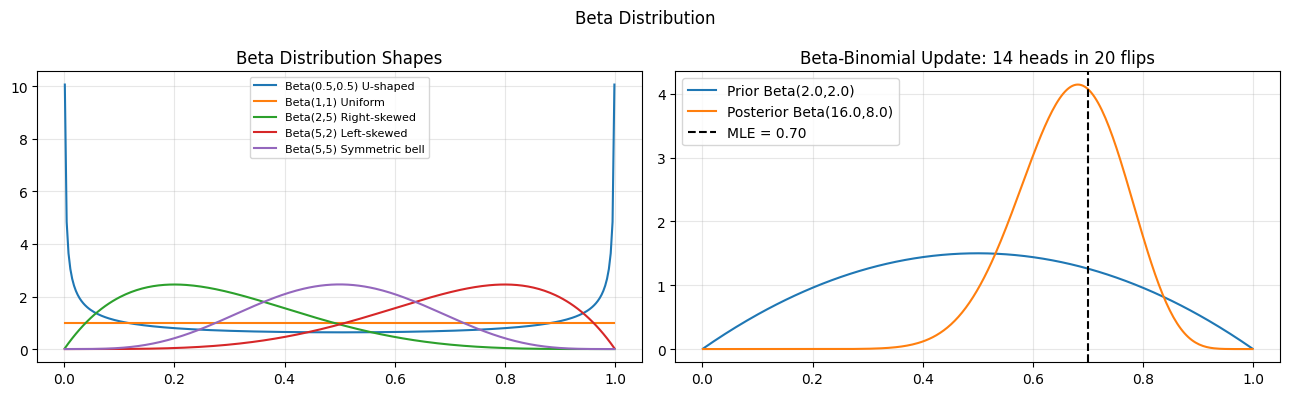

In [5]:
# Beta distribution: X in [0,1], models probabilities and proportions
# Beta(a, b): mean = a/(a+b), mode = (a-1)/(a+b-2) for a,b>1
# Special cases: Beta(1,1) = Uniform, Beta(a,a) = symmetric around 0.5
# Conjugate prior for Binomial (ch261 - Bayesian Inference)

from scipy.stats import beta as beta_dist

x = np.linspace(0.001, 0.999, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
configs_l = [(0.5, 0.5, "U-shaped"), (1, 1, "Uniform"), (2, 5, "Right-skewed"), (5, 2, "Left-skewed"), (5, 5, "Symmetric bell")]
for a, b, label in configs_l:
    axes[0].plot(x, beta_dist.pdf(x, a, b), label=f"Beta({a},{b}) {label}")
axes[0].set_title("Beta Distribution Shapes"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Bayesian coin: update Beta prior with Bernoulli observations
a0, b0 = 2.0, 2.0   # prior: slight belief in fairness
n_flips, k_heads = 20, 14
a_post = a0 + k_heads
b_post = b0 + (n_flips - k_heads)
axes[1].plot(x, beta_dist.pdf(x, a0, b0), label=f"Prior Beta({a0},{b0})")
axes[1].plot(x, beta_dist.pdf(x, a_post, b_post), label=f"Posterior Beta({a_post},{b_post})")
axes[1].axvline(k_heads/n_flips, color="k", ls="--", label=f"MLE = {k_heads/n_flips:.2f}")
axes[1].set_title(f"Beta-Binomial Update: {k_heads} heads in {n_flips} flips")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.suptitle("Beta Distribution"); plt.tight_layout(); plt.show()


## 6. Summary

| Distribution | Support | Key use case |
|---|---|---|
| Exponential(lambda) | [0, inf) | Waiting times, lifetimes |
| Gamma(k, lambda) | [0, inf) | Sum of k exponentials |
| Chi-squared(k) | [0, inf) | Variance, goodness-of-fit |
| t(k) | (-inf, inf) | Mean inference, small samples |
| F(d1, d2) | [0, inf) | Variance ratio tests |
| Beta(a, b) | [0, 1] | Proportions, Bayesian priors |

*(builds on ch253 - Normal Distribution, ch252 - Poisson, ch261 - Bayesian Inference)*

## 7. Forward References

- **ch278 - Hypothesis Testing**: t-test uses the t-distribution; F-test uses the F-distribution.
- **ch280 - p-values**: critical values come from chi-squared and F tails.
- **ch283 - Clustering**: Dirichlet distribution (multivariate beta) in topic models.